# FWI vs. Key Climate Drivers — GFDL-ESM4 (Thailand)

**Analysis:** Annual area-weighted Fire Weather Index (FWI) against four climate drivers
(maximum temperature, precipitation, surface wind speed, and relative humidity)
for Thailand (5.5°–20.5°N, 97.5°–105.5°E) across historical and five SSP scenarios.

**Model:** GFDL-ESM4 | **Source:** CMIP6  
**FWI dataset:** Quilcaille et al. (2023) pre-computed annual FWI (0.25° grid)  
**Driver datasets:** CMIP6 monthly atmospheric variables (1°×1° grid)  

> **Reproducibility note:** Set `DATA_ROOT` in Section 1 to the root folder that
> contains the `FWICMIP6/`, `tasmax/`, `pr/`, `sfcWind/`, and `hurs/` sub-directories.


## 1  Dependencies

In [3]:
# Standard library
from pathlib import Path
from scipy.stats import pearsonr, linregress

# Third-party
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd
import seaborn as sns

## 2  Configuration

Edit `DATA_ROOT` to match your local data directory, then run all cells.


In [5]:
# ── User configuration ───────────────────────────────────────────────────────
DATA_ROOT = Path("/Volumes/jubjang/Jubjang")   # <-- change this if needed

OUTPUT_FILE = "FWI_vs_4drivers_Thailand_2x2.png"

# Study region: Thailand
TH_SLICE = dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))

# Scenario identifiers
SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]

# Display labels (used in legend)
SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119":     "SSP1-1.9",
    "ssp126":     "SSP1-2.6",
    "ssp245":     "SSP2-4.5",
    "ssp370":     "SSP3-7.0",
    "ssp585":     "SSP5-8.5",
}

# Colour-blind-friendly palette (Wong, 2011)
PALETTE = {
    "historical": "#000000",
    "ssp119":     "#E69F00",
    "ssp126":     "#56B4E9",
    "ssp245":     "#009E73",
    "ssp370":     "#882255",
    "ssp585":     "#CC79A7",
}


# Cache directory for precomputed means
CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire-/New /src/GFDL_ESM4/computed_means_GFDL-ESM4")

## 3  Load datasets

All variables are loaded lazily with `xarray.open_mfdataset`; actual data are
read on demand during the analysis step.

| Variable | Units (raw) | Grid |
|---|---|---|
| `fwisa` | dimensionless | 0.25° × 0.25° (annual) |
| `tasmax` | K | ~1° × 1° (monthly) |
| `pr` | kg m⁻² s⁻¹ | ~1° × 1° (monthly) |
| `sfcWind` | m s⁻¹ | ~1° × 1° (monthly) |
| `hurs` | % | ~1° × 1° (monthly) |


In [7]:
def _open(path_pattern):
    """
    Open one or more NetCDF files as a single dataset.

    Accepts a single Path/string (with or without ``*`` glob),
    or a list of Paths/strings.  Glob patterns are expanded with
    ``sorted()`` so the time axis is always in chronological order.
    """
    import glob as _glob

    patterns = path_pattern if isinstance(path_pattern, list) else [path_pattern]

    resolved = []
    for p in patterns:
        p_str = str(p)
        if "*" in p_str or "?" in p_str:
            matched = sorted(_glob.glob(p_str))
            if not matched:
                raise FileNotFoundError(
                    f"No files matched the pattern: {p_str}"
                )
            resolved.extend(matched)
        else:
            resolved.append(p_str)

    return xr.open_mfdataset(
        resolved,
        combine="by_coords",
        engine="netcdf4",
    )


# ── FWI (annual, 0.25° grid) ─────────────────────────────────────────────────
FWI_DIR = DATA_ROOT / "FWICMIP6"

fwi_files = {
    "historical": FWI_DIR / "fwisa_ann_GFDL-ESM4_historical_r1i1p1f1_g025.nc",
    "ssp119":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp119_r1i1p1f1_g025.nc",
    "ssp126":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp126_r1i1p1f1_g025.nc",
    "ssp245":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp245_r1i1p1f1_g025.nc",
    "ssp370":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp370_r1i1p1f1_g025.nc",
    "ssp585":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp585_r1i1p1f1_g025.nc",
}

# ── tasmax (monthly, ~1° grid) ───────────────────────────────────────────────
TAS_DIR = DATA_ROOT / "tasmax"

tasmax_files = {
    "historical": [
        TAS_DIR / "tasmax_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        TAS_DIR / "tasmax_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_201501-210012.nc",
    "ssp126": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── pr (monthly, ~1° grid) ───────────────────────────────────────────────────
PR_DIR = DATA_ROOT / "pr"

pr_files = {
    "historical": [
        PR_DIR / "pr_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        PR_DIR / "pr_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": PR_DIR / "pr_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": PR_DIR / "pr_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": PR_DIR / "pr_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": PR_DIR / "pr_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": PR_DIR / "pr_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── sfcWind (monthly, ~1° grid) ──────────────────────────────────────────────
WIND_DIR = DATA_ROOT / "sfcWind"

sfcwind_files = {
    "historical": [
        WIND_DIR / "sfcWind_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        WIND_DIR / "sfcWind_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── hurs (monthly, ~1° grid) ─────────────────────────────────────────────────
HURS_DIR = DATA_ROOT / "hurs"

hurs_files = {
    "historical": [
        HURS_DIR / "hurs_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        HURS_DIR / "hurs_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── Open all datasets ─────────────────────────────────────────────────────────
ds_fwi    = {s: _open(fwi_files[s])     for s in SCENARIOS}
ds_tasmax = {s: _open(tasmax_files[s])  for s in SCENARIOS}
ds_pr     = {s: _open(pr_files[s])      for s in SCENARIOS}
ds_wind   = {s: _open(sfcwind_files[s]) for s in SCENARIOS}
ds_hurs   = {s: _open(hurs_files[s])    for s in SCENARIOS}

print("All datasets opened successfully.")


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_19201/3641857256.py:26: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.open_mfdataset(
/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_19201/3641857256.py:26: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.open_mfdataset(
/v

All datasets opened successfully.


/var/folders/zt/m4pwqbv546z0ws1g51cnlx600000gn/T/ipykernel_19201/3641857256.py:26: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.open_mfdataset(


## 4  Compute grid-cell area weights

Grid-cell areas are derived analytically from the spherical Earth formula:

$$A_i = R^2 \, \Delta\lambda \, \bigl(\sin\phi_2 - \sin\phi_1\bigr)$$

where $R$ is the Earth's mean radius, $\Delta\lambda$ the longitude spacing,
and $\phi_1, \phi_2$ the latitude bounds of each cell.

Two area grids are constructed because the FWI and driver variables live on
different horizontal resolutions:

| Grid | Shape | Used for |
|---|---|---|
| `areacella` | 72 × 144 | FWI (0.25° native, regridded to 2.5°) |
| `areacella_tas` | 180 × 288 | tasmax / pr / sfcWind / hurs |


In [10]:
def _compute_areacella(lat_coords: np.ndarray, lon_coords: np.ndarray) -> xr.Dataset:
    """
    Return an xr.Dataset with variable ``area`` (km²) on the supplied lat/lon grid.

    Parameters
    ----------
    lat_coords : 1-D array of latitude centres (degrees)
    lon_coords : 1-D array of longitude centres (degrees)
    """
    R = 6_378_137.0  # WGS-84 mean radius (m)

    lat_rad = np.radians(lat_coords)
    lon_rad = np.radians(lon_coords)
    d_lon   = np.diff(lon_rad).mean()
    d_lat   = np.diff(lat_rad).mean()

    area = np.zeros((len(lat_rad), len(lon_rad)))
    for i, phi in enumerate(lat_rad):
        phi1 = phi - d_lat / 2
        phi2 = phi + d_lat / 2
        area[i, :] = R**2 * d_lon * (np.sin(phi2) - np.sin(phi1))

    area_km2 = area / 1e6  # convert m² → km²

    return xr.Dataset({
        "area": xr.DataArray(
            area_km2, dims=["lat", "lon"],
            coords={"lat": lat_coords, "lon": lon_coords},
            attrs={"units": "km2", "long_name": "grid-cell area"},
        )
    })


# FWI grid  (72 lat × 144 lon)
areacella = _compute_areacella(
    lat_coords=np.linspace(-88.75,  88.75,  72),
    lon_coords=np.linspace(  1.25, 358.75, 144),
)

# Driver grid — derived from actual dataset coordinates (robust to any grid)
areacella_tas = _compute_areacella(
    lat_coords=ds_tasmax["historical"].coords["lat"].values,
    lon_coords=ds_tasmax["historical"].coords["lon"].values,
)

print("areacella      →", areacella)
print("areacella_tas  →", areacella_tas)


areacella      → <xarray.Dataset> Size: 85kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 83kB 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03
areacella_tas  → <xarray.Dataset> Size: 418kB
Dimensions:  (lat: 180, lon: 288)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
Data variables:
    area     (lat, lon) float64 415kB 135.2 135.2 135.2 ... 135.2 135.2 135.2


## 5  Analysis helper functions


In [12]:
def _drop_time_dim(da: xr.Dataset) -> xr.Dataset:
    """Remove the time dimension from an area Dataset if present (e.g. after loading)."""
    if "time" in da.dims:
        da = da.isel(time=0)
        da = da.drop_vars([v for v in da.coords if "time" in v], errors="ignore")
    return da


def _annual_mean(ds: xr.Dataset) -> xr.Dataset:
    """Annual mean via groupby (cftime-safe; produces integer year coord)."""
    # return ds.resample(time="YS").mean()
    return ds.groupby("time.year").mean()


def _area_weighted_mean(da: xr.DataArray, weights: xr.Dataset,
                        region: dict) -> xr.DataArray:
    """
    Return the area-weighted spatial mean of *da* over *region*.

    Parameters
    ----------
    da      : DataArray to average (must have lat/lon dims)
    weights : Dataset with an ``area`` variable on a compatible grid
    region  : dict of slice kwargs, e.g. ``dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))``
    """
    da_reg = da.sel(**region)
    w = (
        weights
        .sel(lat=da_reg.lat, lon=da_reg.lon, method="nearest")
        ["area"]
        .assign_coords(lat=da_reg.lat, lon=da_reg.lon)
    )
    return da_reg.weighted(w).mean(dim=["lat", "lon"])


def _compute_var_means_region(
    datasets_dict: dict,
    var:           str,
    scenarios:     list,
    areacella:     xr.Dataset,
    lat_range:     tuple,
    lon_range:     tuple,
) -> dict:
    """
    Area-weighted annual mean of ``var`` over a lat/lon region for all scenarios.
    Returns dict {scenario_key: xr.DataArray (1-D, integer year coord)}.
    """
    result = {}
    lat_min, lat_max = lat_range
    lon_min, lon_max = lon_range
    for scen in scenarios:
        subset   = datasets_dict[scen][var].sel(
            lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
        area_sub = (
            areacella
            .sel(lat=subset.lat, lon=subset.lon, method="nearest")
            ["area"]
            .assign_coords(lat=subset.lat, lon=subset.lon)
        )
        weighted = subset.weighted(area_sub).mean(dim=["lat", "lon"])
        result[scen] = weighted.groupby("time.year").mean()
        print(f"  {scen}: done")
    return result

In [13]:
# ── Compute means (or load from cache if already saved) ──────────────────────
from pathlib import Path
CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire-/New /src/GFDL_ESM4/computed_means_GFDL-ESM4")

def _save_means(means_dict: dict, var_name: str, cache_dir) -> None:
    cache_dir.mkdir(parents=True, exist_ok=True)
    for scen, da in means_dict.items():
        da.to_netcdf(cache_dir / f"{var_name}_{scen}.nc")
    print(f"  saved {len(means_dict)} files  ({var_name}_*.nc)")

def _load_means(var_name: str, scenarios: list, cache_dir) -> dict:
    return {
        scen: xr.open_dataarray(cache_dir / f"{var_name}_{scen}.nc")
        for scen in scenarios
        if (cache_dir / f"{var_name}_{scen}.nc").exists()
    }

def _is_cached(var_name: str, scenarios: list, cache_dir) -> bool:
    return all((cache_dir / f"{var_name}_{scen}.nc").exists() for scen in scenarios)

_vars = ["fwi", "tasmax", "pr", "sfcWind", "hurs"]
_lat  = (TH_SLICE["lat"].start, TH_SLICE["lat"].stop)
_lon  = (TH_SLICE["lon"].start, TH_SLICE["lon"].stop)
_kw   = dict(scenarios=SCENARIOS, lat_range=_lat, lon_range=_lon)

if all(_is_cached(v, SCENARIOS, CACHE_DIR) for v in _vars):
    print("Cache found — loading from disk.")
    ensemble_means_th_all_scenarios = _load_means("fwi",     SCENARIOS, CACHE_DIR)
    tasmax_means_all_scenarios      = _load_means("tasmax",  SCENARIOS, CACHE_DIR)
    pr_means_all_scenarios          = _load_means("pr",      SCENARIOS, CACHE_DIR)
    sfcWind_means_all_scenarios     = _load_means("sfcWind", SCENARIOS, CACHE_DIR)
    hurs_means_all_scenarios        = _load_means("hurs",    SCENARIOS, CACHE_DIR)
    for _d in [ensemble_means_th_all_scenarios, tasmax_means_all_scenarios,
               pr_means_all_scenarios, sfcWind_means_all_scenarios, hurs_means_all_scenarios]:
        for _da in _d.values(): _da.load()
else:
    print("No cache — computing from raw data.")
    print("── FWI ────────────────────────────────────────────────────────────")
    ensemble_means_th_all_scenarios = _compute_var_means_region(
        ds_fwi, "fwisa", areacella=areacella, **_kw)
    print("── tasmax ─────────────────────────────────────────────────────────")
    tasmax_means_all_scenarios = _compute_var_means_region(
        ds_tasmax, "tasmax", areacella=areacella_tas, **_kw)
    print("── pr ─────────────────────────────────────────────────────────────")
    pr_means_all_scenarios = _compute_var_means_region(
        ds_pr, "pr", areacella=areacella_tas, **_kw)
    print("── sfcWind ────────────────────────────────────────────────────────")
    sfcWind_means_all_scenarios = _compute_var_means_region(
        ds_wind, "sfcWind", areacella=areacella_tas, **_kw)
    print("── hurs ───────────────────────────────────────────────────────────")
    hurs_means_all_scenarios = _compute_var_means_region(
        ds_hurs, "hurs", areacella=areacella_tas, **_kw)

    print("Saving to cache...")
    _save_means(ensemble_means_th_all_scenarios, "fwi",     CACHE_DIR)
    _save_means(tasmax_means_all_scenarios,      "tasmax",  CACHE_DIR)
    _save_means(pr_means_all_scenarios,          "pr",      CACHE_DIR)
    _save_means(sfcWind_means_all_scenarios,     "sfcWind", CACHE_DIR)
    _save_means(hurs_means_all_scenarios,        "hurs",    CACHE_DIR)

print("Ready.")
for scen in SCENARIOS:
    t = ensemble_means_th_all_scenarios[scen]["year"]
    print(f"  {scen}: {t.values[0]} → {t.values[-1]}  ({len(t)} years)")

No cache — computing from raw data.
── FWI ────────────────────────────────────────────────────────────
  historical: done
  ssp119: done
  ssp126: done
  ssp245: done
  ssp370: done
  ssp585: done
── tasmax ─────────────────────────────────────────────────────────
  historical: done
  ssp119: done
  ssp126: done
  ssp245: done
  ssp370: done
  ssp585: done
── pr ─────────────────────────────────────────────────────────────
  historical: done
  ssp119: done
  ssp126: done
  ssp245: done
  ssp370: done
  ssp585: done
── sfcWind ────────────────────────────────────────────────────────
  historical: done
  ssp119: done
  ssp126: done
  ssp245: done
  ssp370: done
  ssp585: done
── hurs ───────────────────────────────────────────────────────────
  historical: done
  ssp119: done
  ssp126: done
  ssp245: done
  ssp370: done
  ssp585: done
Saving to cache...
  saved 6 files  (fwi_*.nc)
  saved 6 files  (tasmax_*.nc)
  saved 6 files  (pr_*.nc)
  saved 6 files  (sfcWind_*.nc)
  saved 6 files  

## 6  Plotting function

`plot_fwi_vs_4vars_grid` produces a 2 × 2 panel figure showing area-weighted
annual FWI against each of the four climate drivers for all scenarios.
A linear regression line is overlaid on each scatter cloud.


In [15]:
def plot_fwi_vs_4vars_grid(
    fwi_means:    dict,
    tasmax_means: dict,
    pr_means:     dict,
    wind_means:   dict,
    hurs_means:   dict,
    scenarios:    list,
    labels:       dict,
    palette:      dict,
    filename:     str = OUTPUT_FILE,
) -> None:
    """
    2 × 2 scatter: FWI vs four climate drivers.
    Each input dict is {scenario_key: xr.DataArray (1-D, integer year coord)}.
    Unit conversions applied here: tasmax K→°C, pr kg m⁻² s⁻¹→mm day⁻¹.
    """
    panels = [
        dict(key="tasmax", drv=tasmax_means, xlabel="Maximum Temperature (°C)",   label="a)"),
        dict(key="pr",     drv=pr_means,     xlabel="Precipitation (mm day⁻¹)",   label="b)"),
        dict(key="wind",   drv=wind_means,   xlabel="Surface Wind Speed (m s⁻¹)", label="c)"),
        dict(key="hurs",   drv=hurs_means,   xlabel="Relative Humidity (%)",       label="(d)"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(5.51, 4.3),
                             constrained_layout=True, sharey="row")
    axes = axes.flatten()
    legend_handles = {}

    for ax, panel in zip(axes, panels):
        var = panel["key"]
        ax.set_title(panel["label"], loc="left", fontsize=13)

        for scen in scenarios:
            fwi_da = fwi_means[scen]
            t      = fwi_da["year"]
            y_vals = fwi_da.values
            drv_da = panel["drv"][scen].sel(year=t, method="nearest")

            if var == "tasmax":
                x_vals = (drv_da - 273.15).values
            elif var == "pr":
                x_vals = (drv_da * 86_400.0).values
            else:
                x_vals = drv_da.values

            mask = (~np.isnan(x_vals)) & (~np.isnan(y_vals))
            x_vals, y_vals_m = x_vals[mask], y_vals[mask]
            if x_vals.size == 0 or x_vals.size != y_vals_m.size:
                continue

            color = palette.get(scen, "#000000")
            sc = ax.scatter(x_vals, y_vals_m, s=5, alpha=0.6, color=color)
            slope, intercept, *_ = linregress(x_vals, y_vals_m)
            x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, "-", lw=1.5, color=color)
            lbl = labels.get(scen, scen)
            if lbl not in legend_handles:
                legend_handles[lbl] = sc

        ax.set_xlabel(panel["xlabel"], fontsize=11)
        ax.set_ylim(0, 50)
        ax.grid(True, linestyle="solid", alpha=0.6)
        ax.tick_params(labelsize=10)

    for idx, ax in enumerate(axes):
        if idx % 2 == 0:
            ax.set_ylabel("FWI", fontsize=13)
        else:
            ax.set_ylabel(None)
            ax.tick_params(labelleft=False)

    fig.legend(legend_handles.values(), legend_handles.keys(),
               loc="upper center", bbox_to_anchor=(0.5, 0.01),
               ncol=3, frameon=False, fontsize=10)
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Figure saved → {filename}")
    plt.show()

## 7.1 Generate figure

Figure saved → FWI_vs_4drivers_Thailand_2x2.png


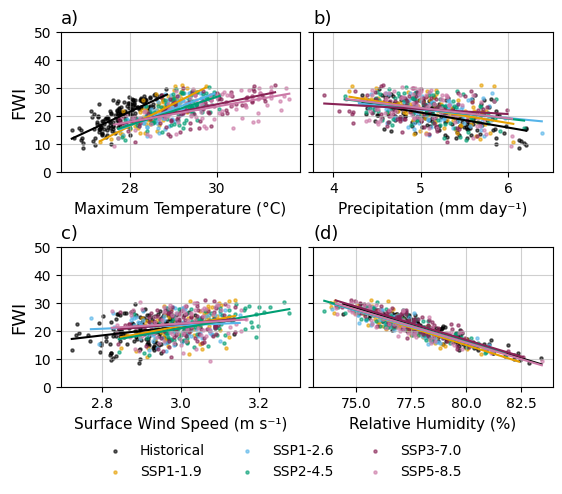

In [17]:
# ── 4-panel scatter: FWI vs 4 drivers ─────────────────────────────────────────
from pathlib import Path
_cd = Path("/Users/thunthita/ClimateChangeonWildfire-/New /src/GFDL_ESM4/computed_means_GFDL-ESM4")
_ld = lambda v: {s: xr.open_dataarray(_cd / f"{v}_{s}.nc").load() for s in SCENARIOS if (_cd / f"{v}_{s}.nc").exists()}

plot_fwi_vs_4vars_grid(
    fwi_means    = _ld("fwi"),
    tasmax_means = _ld("tasmax"),
    pr_means     = _ld("pr"),
    wind_means   = _ld("sfcWind"),
    hurs_means   = _ld("hurs"),
    scenarios    = SCENARIOS,
    labels       = SCENARIO_LABELS,
    palette      = PALETTE,
    filename     = OUTPUT_FILE,
)

## 7.2 Generate Heatmap

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_fwi_corr_heatmap(
    fwi_means:    dict,
    tasmax_means: dict,
    pr_means:     dict,
    wind_means:   dict,
    hurs_means:   dict,
    scenarios:    list,
    labels:       dict,
    filename:     str = "fwi_correlation_matrix_GFDL-ESM4.png",
) -> None:
    """
    Heatmap of Pearson r between FWI and each climate driver, one row per scenario.
    Each input dict is {scenario_key: xr.DataArray (1-D, integer year coord)}.
    Unit conversions applied here: tasmax K→°C, pr kg m⁻² s⁻¹→mm day⁻¹.
    """
    corr_data = []
    for scen in scenarios:
        fwi_da = fwi_means[scen]
        t      = fwi_da["year"]
        fwi_v  = fwi_da.values
        tas_v  = (tasmax_means[scen].sel(year=t, method="nearest") - 273.15  ).values
        pr_v   = (pr_means[scen].sel(   year=t, method="nearest") * 86_400.0).values
        wind_v =  wind_means[scen].sel( year=t, method="nearest").values
        hurs_v =  hurs_means[scen].sel( year=t, method="nearest").values

        df = pd.DataFrame({
            "FWI":      fwi_v,
            "Max Temp": tas_v,
            "Precip":   pr_v,
            "Wind":     wind_v,
            "Humidity": hurs_v,
        }).corr()
        row      = df["FWI"].drop("FWI")
        row.name = labels.get(scen, scen)
        corr_data.append(row)

    final_corr_matrix = pd.concat(corr_data, axis=1).T

    plt.figure(figsize=(8, len(scenarios) * 1.2))
    sns.set_context("talk")
    sns.heatmap(final_corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, cbar_kws={"label": "Pearson correlation (r)"}, linewidths=0.5)
    plt.title("Correlation: FWI vs Climate Drivers", pad=20)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

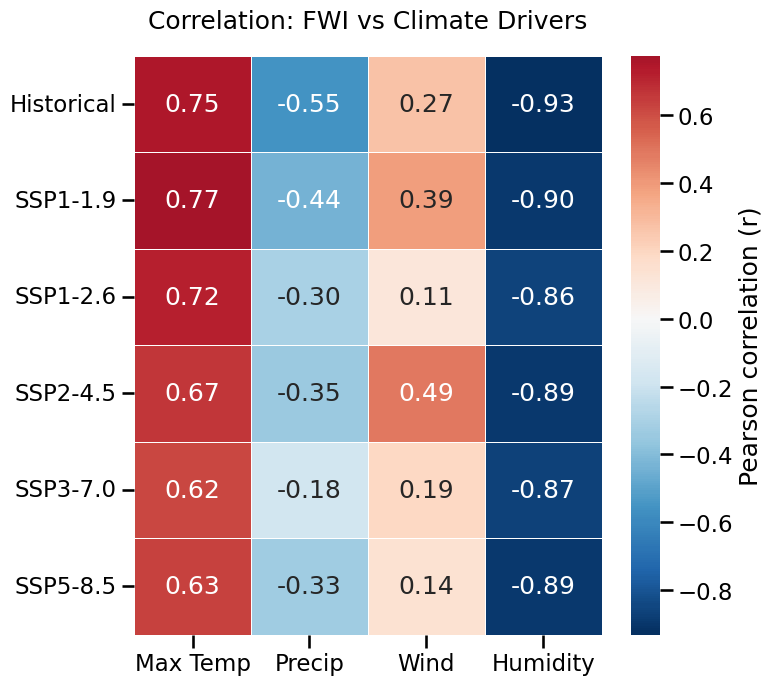

In [44]:
# ── Correlation heatmap: FWI vs 4 drivers ─────────────────────────────────────
from pathlib import Path
_cd = Path("/Users/thunthita/ClimateChangeonWildfire-/New /src/GFDL_ESM4/computed_means_GFDL-ESM4")
_ld = lambda v: {s: xr.open_dataarray(_cd / f"{v}_{s}.nc").load() for s in SCENARIOS if (_cd / f"{v}_{s}.nc").exists()}

plot_fwi_corr_heatmap(
    fwi_means    = _ld("fwi"),
    tasmax_means = _ld("tasmax"),
    pr_means     = _ld("pr"),
    wind_means   = _ld("sfcWind"),
    hurs_means   = _ld("hurs"),
    scenarios    = SCENARIOS,
    labels       = SCENARIO_LABELS,
    filename     = "fwi_correlation_matrix_GFDL-ESM4.png",
)

In [21]:
## 8  Pearson correlation, slope & intercept (driver vs FWI)
from scipy.stats import pearsonr, linregress
import pandas as pd

def pearson_driver_vs_fwi(
    fwi_means:    dict,
    driver_means: dict,
    var_label:    str,
    scenarios:    list,
    labels:       dict,
    scale:        float = 1.0,
    offset:       float = 0.0,
) -> pd.DataFrame:
    """
    Pearson r, slope, intercept between one climate driver and FWI.
    scale/offset applied to driver for unit conversion (e.g. tasmax K→°C).
    """
    combined_drv, combined_fwi = [], []
    rows = []
    for scen in scenarios:
        fwi_da = fwi_means[scen]
        t      = fwi_da["year"]
        fwi_v  = fwi_da.values
        drv_v  = (driver_means[scen].sel(year=t, method="nearest") * scale + offset).values

        mask = ~np.isnan(drv_v) & ~np.isnan(fwi_v)
        drv_v, fwi_v = drv_v[mask], fwi_v[mask]
        if len(drv_v) < 2:
            continue
        r, _                 = pearsonr(drv_v, fwi_v)
        slope, intercept, *_ = linregress(drv_v, fwi_v)
        rows.append({"Scenario": labels[scen], "r": round(r, 4),
                     "slope": round(slope, 4), "intercept": round(intercept, 4)})
        combined_drv.extend(drv_v)
        combined_fwi.extend(fwi_v)

    if combined_drv:
        r, _                 = pearsonr(combined_drv, combined_fwi)
        slope, intercept, *_ = linregress(combined_drv, combined_fwi)
        rows.append({"Scenario": "ALL (combined)", "r": round(r, 4),
                     "slope": round(slope, 4), "intercept": round(intercept, 4)})

    df = pd.DataFrame(rows)
    print(f"\n── {var_label} vs FWI — Thailand ──")
    print(df.to_string(index=False))
    return df

In [22]:
# ── Pearson correlation: FWI vs 4 drivers ────────────────────────────────────
from pathlib import Path
_cd = Path("/Users/thunthita/ClimateChangeonWildfire-/New /src/GFDL_ESM4/computed_means_GFDL-ESM4")
_ld = lambda v: {s: xr.open_dataarray(_cd / f"{v}_{s}.nc").load() for s in SCENARIOS if (_cd / f"{v}_{s}.nc").exists()}

_fwi  = _ld("fwi")
_tas  = _ld("tasmax")
_pr   = _ld("pr")
_wind = _ld("sfcWind")
_hurs = _ld("hurs")

df_tasmax = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_tas,
    var_label="tasmax (°C)", scenarios=SCENARIOS, labels=SCENARIO_LABELS,
    scale=1.0, offset=-273.15)

df_pr = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_pr,
    var_label="pr (mm day⁻¹)", scenarios=SCENARIOS, labels=SCENARIO_LABELS,
    scale=86_400.0)

df_wind = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_wind,
    var_label="sfcWind (m s⁻¹)", scenarios=SCENARIOS, labels=SCENARIO_LABELS)

df_hurs = pearson_driver_vs_fwi(fwi_means=_fwi, driver_means=_hurs,
    var_label="hurs (%)", scenarios=SCENARIOS, labels=SCENARIO_LABELS)


── tasmax (°C) vs FWI — Thailand ──
      Scenario      r  slope  intercept
    Historical 0.7510 7.1931  -179.9720
      SSP1-1.9 0.7748 7.8510  -203.4908
      SSP1-2.6 0.7182 5.8703  -147.8194
      SSP2-4.5 0.6654 5.0255  -124.0146
      SSP3-7.0 0.6157 3.2053   -72.0587
      SSP5-8.5 0.6325 2.7398   -58.8691
ALL (combined) 0.5859 2.7400   -57.2842

── pr (mm day⁻¹) vs FWI — Thailand ──
      Scenario       r   slope  intercept
    Historical -0.5518 -5.3564    47.9402
      SSP1-1.9 -0.4421 -5.1712    48.4623
      SSP1-2.6 -0.3017 -3.0398    37.4454
      SSP2-4.5 -0.3513 -3.6968    41.1522
      SSP3-7.0 -0.1760 -1.7849    31.3523
      SSP5-8.5 -0.3265 -3.7050    41.3401
ALL (combined) -0.4011 -4.2109    43.1573

── sfcWind (m s⁻¹) vs FWI — Thailand ──
      Scenario      r   slope  intercept
    Historical 0.2720 16.1811   -26.9306
      SSP1-1.9 0.3872 25.9331   -56.1072
      SSP1-2.6 0.1132  5.8874     4.2726
      SSP2-4.5 0.4910 24.6035   -52.8979
      SSP3-7.0 0.1905 

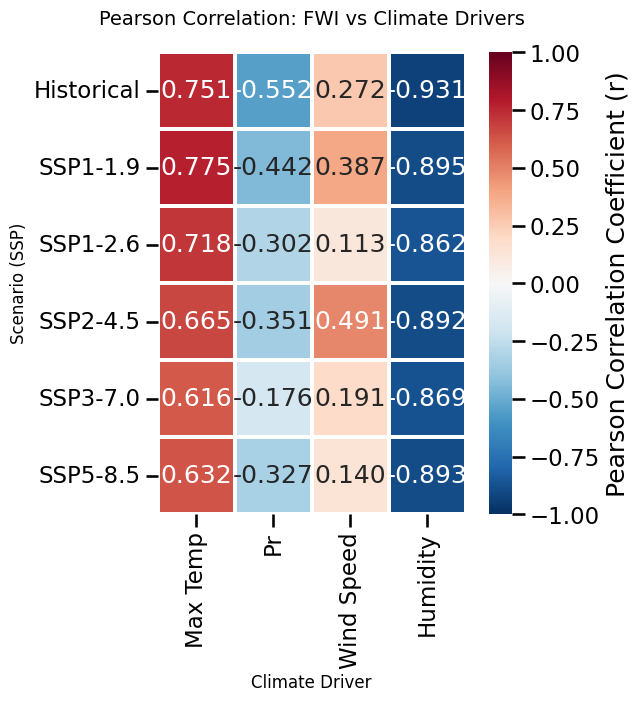

In [23]:
# 1. List your existing DataFrames and their corresponding variable names
dfs = [df_tasmax, df_pr, df_wind, df_hurs]
var_names = ["Max Temp", "Pr", "Wind Speed", "Humidity"]

# 2. Extract and combine
combined_r = []
for df, name in zip(dfs, var_names):
    s = df.set_index("Scenario")["r"]
    s.name = name  
    combined_r.append(s)

master_corr_matrix = pd.concat(combined_r, axis=1)
master_corr_matrix = master_corr_matrix.drop("ALL (combined)", errors='ignore')

# 3. Plot the Heatmap with fixed scale -1 to 1
plt.figure(figsize=(6, 6))
sns.heatmap(
    master_corr_matrix, 
    annot=True, 
    cmap="RdBu_r", 
    center=0, 
    vmin=-1,          # Force scale start at -1
    vmax=1,           # Force scale end at 1
    fmt=".3f", 
    linewidths=1.5,
    square=True,      # Makes cells square-shaped
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'}
)

plt.title("Pearson Correlation: FWI vs Climate Drivers", fontsize=14, pad=20)
plt.ylabel("Scenario (SSP)", fontsize=12)
plt.xlabel("Climate Driver", fontsize=12)

# Optional: Rotate scenario labels for better readability
plt.yticks(rotation=0)
plt.show()